# Import Libraries

In [251]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Write a Python function for $f(\theta)$
Write a Matlab function file for $f(\theta)$. The parameters $L_1, L_2, L_3, \gamma, x_1, x_2, y_2$ are fixed constants, and the strut lengths $p_1, p_2, p_3$ will be known for a given pose. To test your code, set the parameters $L_1 = 2$, $L_2 = L_3 = \sqrt{2}$, $\gamma = \pi/2$, and $p_1 = p_2 = p_3 = \sqrt{5}$. Then, substituting $\theta = -\pi/4$ or $\theta = \pi/4$, should make $f(\theta) = 0$.

## Create function for $f(\theta)$

In [252]:

def f(theta):
    """
    Calculates a value based on the given angle theta.

    Parameters:
    theta (float): The angle in radians.

    Returns:
    float: The calculated result.

    Raises:
    ZeroDivisionError: If the denominator D is zero.
    """
    # Calculate intermediate values A2, B2, A3, B3
    A2 = (L3 * np.cos(theta)) - X1
    B2 = L3 * np.sin(theta)
    
    A3 = L2 * ((np.cos(theta) * np.cos(GAMA)) - (np.sin(theta) * np.sin(GAMA))) - X2
    B3 = L2 * ((np.cos(theta) * np.sin(GAMA)) - (np.sin(theta) * np.cos(GAMA))) - Y2
    
    # Calculate N1, N2, and D
    N1 = (B3 * ((P2 ** 2) - (P1 ** 2) - (A2 ** 2) - (B2 ** 2))) - (B2 * ((P3 ** 2) - (P1 ** 2) - (A3 ** 2) - (B3 ** 2)))
    N2 = ((-1 * A3) * ((P2 ** 2) - (P1 ** 2) - (A2 ** 2) - (B2 ** 2))) + (A2 * ((P3 ** 2) - (P1 ** 2) - (A3 ** 2) - (B3 ** 2)))
    
    D = 2 * ((A2 * B3) - (B2 * A3))
    
    # Check for division by zero
    if D == 0:
        raise ZeroDivisionError("D cannot be zero, division by zero error.")
    
    x = N1 / D
    y = N2 / D

    # Continue with calculations involving D (if applicable)
    result = (N1 ** 2) + (N2 ** 2) - ((P1 ** 2) * (D ** 2))
    
    return result, x, y



## Test function $f(\theta)$

In [253]:
# Constants
L1 = 2
L2 = np.sqrt(2)
L3 = np.sqrt(2)
GAMA = np.pi / 2
P1 = np.sqrt(5)
P2 = np.sqrt(5)
P3 = np.sqrt(5)
X0 = 0
Y0 = 0
X1 = 4
Y1 = 0
X2 = 0
Y2 = 4

theta = np.pi / 4

result, x, y = f(theta)
print(f'f(θ) = {result}\nx = {x}\ny = {y}')

f(θ) = -4.547473508864641e-13
x = 2.0
y = 1.0


# 2. Plot $f(\theta)$ on $[-π, π]$

## Create Plot

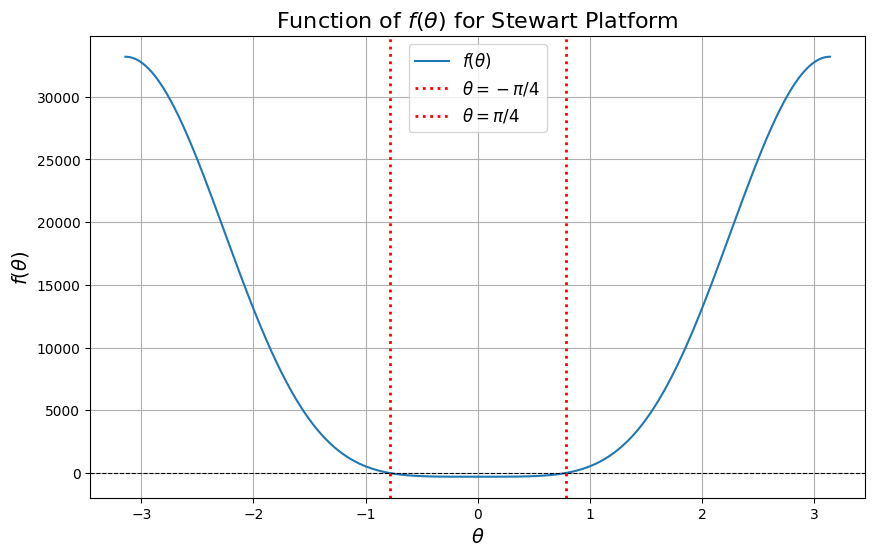

In [254]:
theta_values = np.linspace(-np.pi, np.pi, 1000)
results = []
for theta in theta_values:
    try:
        res, _, _ = f(theta)
        results.append(res)
    except ZeroDivisionError:
        results.append(np.nan)


plt.figure(figsize=(10, 6))
plt.plot(theta_values, results, label=r'$f(\theta)$')  # Default linewidth
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Default linewidth
plt.axvline(-np.pi/4, color='red', linestyle=':', linewidth=2, label=r'$\theta = -\pi/4$')  # Increased linewidth
plt.axvline(np.pi/4, color='red', linestyle=':', linewidth=2, label=r'$\theta = \pi/4$')  # Increased linewidth
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$f(\theta)$', fontsize=14)
plt.title(r'Function of $f(\theta)$ for Stewart Platform', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 3. Reproduce Figure 1.15.

Reproduce Figure 1.15. Use the following Matlab commands to plot a red triangle with vertices $(u_1, v_1), (u_2, v_2), (u_3, v_3)$ and place small blue circles at the strut anchor points $(0,0), (x_1, 0), (x_2, y_2)$:

In [255]:
def get_points(x, y, theta, gama):
    L1_point = (x,y)
    
    L2_x = x + (L3 * np.cos(theta))
    L2_y = y + (L3 * np.sin(theta))
    
    L2_point = (np.round(L2_x), np.round(L2_y))
    
    L3_x = x + (L2 * np.cos(theta + gama))
    L3_y = y + (L2 * np.sin(theta + gama))
    
    L3_point = (np.round(L3_x), np.round(L3_y))
    
    return [L1_point, L2_point, L3_point]

def get_anchor_points(x1, x2, y2):
    L1_point = (x,y)
    
    L2_x = x + (L3 * np.cos(theta))
    L2_y = y + (L3 * np.sin(theta))
    
    L2_point = (np.round(L2_x), np.round(L2_y))
    
    L3_x = x + (L2 * np.cos(theta + gama))
    L3_y = y + (L2 * np.sin(theta + gama))
    
    L3_point = (np.round(L3_x), np.round(L3_y))
    
    return [(0, 0), (x1, 0), (x2, y2)]

def plot_triangle(ax, points, anchor_points):
    """
    Plots a triangle with small open circles at each of the points
    and small blue circles at the strut anchor points on a given axis.
    The triangle is rendered with lines connecting each point.
    
    Parameters:
    ax (matplotlib axis): Axis to plot on.
    points (list of tuples or numpy array): Points representing the vertices of the triangle.
    anchor_points (list of tuples or numpy array): Anchor points for the strut.
    """
    
    # Ensure points and anchor_points are numpy arrays
    points = np.array(points)
    anchor_points = np.array(anchor_points)
    
    # Check if the input is in the correct shape (3x2)
    if points.shape != (3, 2):
        raise ValueError("Input should be a list of 3 points, each as a pair of (x, y) coordinates.")
    
    # Extract the x and y coordinates for the triangle vertices
    x_coords = points[:, 0]
    y_coords = points[:, 1]
    
    # Close the triangle by repeating the first point at the end
    x_closed = np.append(x_coords, x_coords[0])
    y_closed = np.append(y_coords, y_coords[0])
    
    # Extract the x and y coordinates for the anchor points
    anchor_x = anchor_points[:, 0]
    anchor_y = anchor_points[:, 1]
    
    # Plot the triangle
    ax.plot(x_closed, y_closed, 'r-', linewidth=3.5)
    
    # Plot red dots at the triangle vertices
    ax.plot(x_coords, y_coords, 'bo', markersize=8)
    
    # Plot lines from base points to corresponding triangle vertices
    for i, anchor in enumerate(anchor_points):
        ax.plot([anchor[0], points[i, 0]], [anchor[1], points[i, 1]], 'b-', linewidth=1.5)
    
    # Plot small blue circles at the strut anchor points
    ax.plot(anchor_x, anchor_y, 'bo', markersize=8)
    
    # Set labels and title
    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    # Set the domain and range for both axes
    ax.set_xlim(-0.25, 4.25)
    ax.set_ylim(-0.25, 4.25)
    
    # Add grid for better visualization
    ax.grid(True)

    

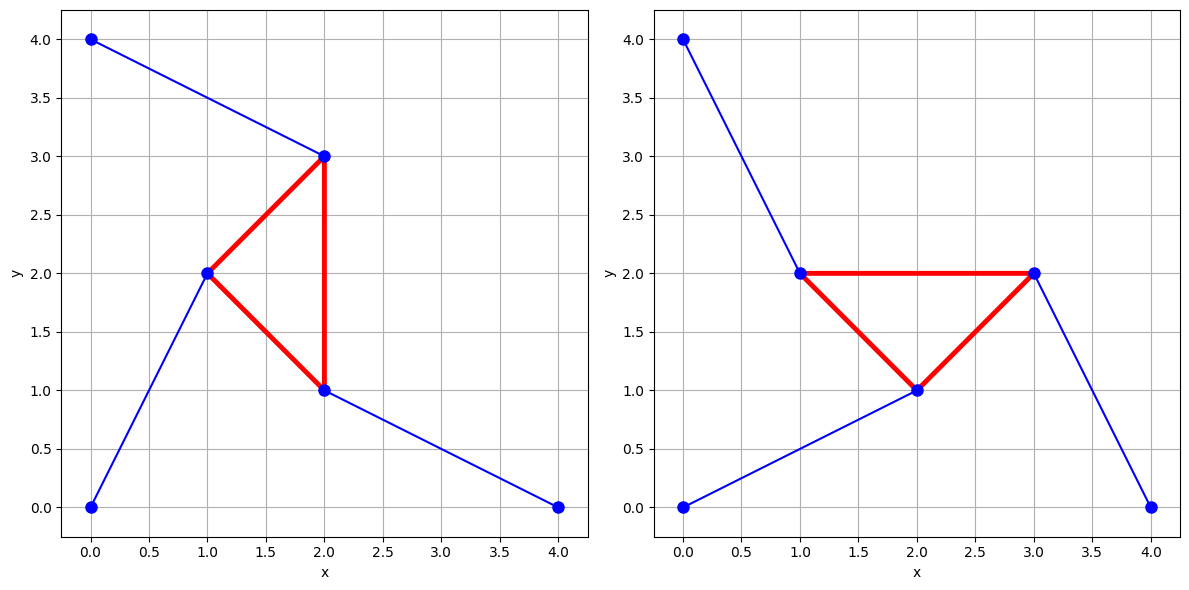

In [256]:
theta = np.pi / 4
theta_negative = -np.pi / 4
gama = np.pi / 2

_, x, y = f(theta_negative)

points1 = get_points(x, y, theta_negative, gama)
anchor_points = get_anchor_points(4, 0, 4)

_, x, y = f(theta)
points2 = get_points(x, y, theta, gama)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot first triangle on the first axis
plot_triangle(axes[0], points1, anchor_points)

# Plot second triangle on the second axis
plot_triangle(axes[1], points2, anchor_points)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the concatenated plots
plt.show()